# RL-16 : Dream-RSI — l'exploration comme code, évaluée off-policy par monde-replay

| | |
|---|---|
| **Série** : Reinforcement Learning | **Prérequis** : [RL-8](rl_8_model_based_dyna_q.ipynb) (Dyna-Q), [RL-3](rl_3_experience_replay_her.ipynb) (replay), [RL-13](rl_13_curiosity_exploration.ipynb) (exploration) |
| **Sources** : Zheng et al., *Dream-RSI: Recursive Self-Improvement through Evolving Worlds*, arXiv:2609.14858 | **Genre** : distillation SOTA-Comparison (monde jouet) |

> **Statut de la source.** Preprint cs.CL soumis le 14/09/2026, non relu, 18 auteurs. Ses
> chiffres (162× moins d'appels que SimpleTES sur Lasso, 2.09× sur KernelBench) sont des
> *claims d'auteurs* obtenus avec un agent Gemini-3.1 Pro hors de portée d'un cours. Ce
> notebook reproduit le **mécanisme** — pas les benchmarks — sur un monde jouet exécutable
> en pur Python standard, sans LLM ni GPU.

## L'idée en une table : Dream-RSI est du Dyna transposé aux agents

Le papier revendique lui-même la filiation (*« This idea parallels model-based
reinforcement learning (Sutton, 1990) »*). La table de correspondance s'écrit toute seule :

| Dyna (RL-8, Sutton 1990) | Dream-RSI (ce notebook) |
|---|---|
| modèle appris de l'environnement | arbres de découverte **enregistrés** (les « mondes ») |
| planning : simulations depuis le modèle | dreaming : marches **off-policy** sur les arbres figés |
| amélioration de la politique (Q) | sélection de la **politique d'exploration** |
| boucle act → learn → plan → act | boucle explore → enregistre → rêve → redéploie |

Le point conceptuel fort : dans Dream-RSI, **la politique d'exploration est du code
exécutable** (elle choisit quels nœuds étendre, la largeur des batches, quand s'arrêter),
et ce code peut être **révisé en rêvant** — évalué à coût nul sur l'historique enregistré
avant d'être redéployé en ligne. C'est une boucle d'auto-amélioration récursive (RSI) à la
couche méta-exploration : l'agent qui cherche n'est pas modifié, c'est la façon de chercher
qui évolue.

In [1]:
import math
import random
from dataclasses import dataclass, field

import matplotlib.pyplot as plt

SEED = 42
print("seed globale :", SEED)

seed globale : 42


## 1. Le monde jouet : empilement de cercles (circle packing)

Deux des trois domaines mathématiques du papier (circle packing, autocorrélation) sont
reproductibles avec la seule bibliothèque standard — aucun LLM requis. On prend le
**circle packing** : placer $n$ cercles dans le carré unité en maximisant les distances
par paires.

Le contrat important est le **coût** : appeler `packing_score` = un appel à
l'environnement. C'est l'unité de budget du monde Dream-RSI jouet, exactement comme un
appel d'agent dans le papier.

In [2]:
N_CIRCLES = 16
R_MAX = 0.10  # rayon « utile » : deux cercles plus proches que 2R se gênent


def dist(a, b):
    return math.hypot(a[0] - b[0], a[1] - b[1])


def packing_score(config):
    """Qualité d'un empilement : distances par paires saturées à 2R, moins une
    pénalité forte de chevauchement. UN appel = UN coût d'environnement."""
    s = 0.0
    for i in range(len(config)):
        for j in range(i + 1, len(config)):
            d = dist(config[i], config[j])
            s += min(d, 2 * R_MAX)
            if d < 2 * R_MAX:
                s -= (2 * R_MAX - d) * 5.0
    return s


def random_config(rng):
    return [(rng.random(), rng.random()) for _ in range(N_CIRCLES)]


def mutate(config, rng, sigma=0.15):
    """Déplacer un seul cercle selon un bruit gaussien borné au carré : le plus
    petit « candidat de recherche » voisin d'une configuration."""
    child = [list(p) for p in config]
    k = rng.randrange(len(child))
    child[k][0] = min(1.0, max(0.0, child[k][0] + rng.gauss(0, sigma)))
    child[k][1] = min(1.0, max(0.0, child[k][1] + rng.gauss(0, sigma)))
    return [tuple(p) for p in child]


config0 = random_config(random.Random(SEED))
print(f"score de la configuration initiale : {packing_score(config0):.4f}")

score de la configuration initiale : 17.1273


**Lecture chiffree — le point de depart et son plafond.** `score de la configuration initiale : 17.1273`. Le plafond du scorer se derive de la source : 16 cercles font 16 x 15 / 2 = **120 paires**, chaque paire contribue au plus `min(d, 2R)` avec `R_MAX = 0.10`, soit 120 x 0.2 = **24.0** — la valeur que la boucle RSI ci-dessous atteindra exactement. Le random de depart vaut donc 17.1273 / 24.0, environ 71 % du plafond, penalite de chevauchement incluse (chaque paire trop proche perd `(2R - d) x 5`, source) : la marge restante est ce que l'exploration doit gagner.


## 2. L'arbre de découverte : l'historique comme structure première

Une session de recherche en ligne n'est pas une liste de solutions : c'est un **arbre**.
Chaque nœud porte sa configuration, son observation (le score) et ses enfants — les
candidats effectivement proposés et **payés**. Dans Dream-RSI, cet arbre figé est la
matière première : il devient un « monde » rejouable.

In [3]:
@dataclass
class Node:
    config: tuple
    score: float
    depth: int = 0
    children: list = field(default_factory=list)
    visits: int = 0


def expand(node, rng, batch_size, sigma=0.15):
    """UN appel d'agent : proposer `batch_size` mutations depuis le nœud, les
    évaluer, les ENREGISTRER dans l'arbre. Coût : 1 batch, quelle que soit la
    largeur — comme dans le papier, le coût porte sur l'appel, pas sur le
    parallélisme interne du batch."""
    children = []
    for _ in range(batch_size):
        cfg = mutate(node.config, rng, sigma)
        children.append(Node(tuple(cfg), packing_score(cfg), node.depth + 1))
    node.children = children
    node.visits += 1
    return children


def tree_size(root):
    n, stack = 0, [root]
    while stack:
        node = stack.pop()
        n += 1
        stack.extend(node.children)
    return n

## 3. La politique d'exploration est du code

L'agent qui propose des mutations est **inchangé** (fonction `mutate`). Ce qui varie,
c'est la politique qui décide **quel nœud de la frontière étendre** et **avec quelle
largeur** — et cette politique est un objet Python ordinaire : une classe avec une
méthode `select()`. C'est la transposition jouet de « l'exploration explicite et
programmable » du papier : parce que la politique est du code, on peut en générer des
variantes et les comparer.

In [4]:
class FixedRefinement:
    """Raffinement parallèle figé (baseline du papier) : toujours approfondir
    le meilleur point connu, avec une largeur de batch constante."""

    def __init__(self, batch_size=4):
        self.batch_size = batch_size

    def select(self, frontier, rng):
        return max(frontier, key=lambda n: n.score)


class EpsilonGreedy:
    """ε-greedy : le meilleur point connu, sauf avec probabilité ε où l'on
    diversifie vers un nœud aléatoire de la frontière."""

    def __init__(self, eps, batch_size=4):
        self.eps = eps
        self.batch_size = batch_size

    def select(self, frontier, rng):
        if rng.random() < self.eps:
            return rng.choice(frontier)
        return max(frontier, key=lambda n: n.score)


def run_online(policy, rng, n_batches=30):
    """Une session EN LIGNE : la politique dépense `n_batches` appels d'agent.
    Renvoie la racine de l'arbre enregistré (le « monde »), le meilleur score
    trouvé et la frontière restante."""
    cfg0 = tuple(random_config(rng))
    root = Node(cfg0, packing_score(cfg0))
    frontier = [root]
    for _ in range(n_batches):
        node = policy.select(frontier, rng)
        frontier.remove(node)
        frontier.extend(expand(node, rng, policy.batch_size))
    return root, tree_best(root).score, frontier


def tree_best(root):
    """Le nœud de meilleur score de tout l'arbre (récursif-itératif)."""
    best, stack = root, [root]
    while stack:
        node = stack.pop()
        if node.score > best.score:
            best = node
        stack.extend(node.children)
    return best

## 4. Le replay déterministe : rêver sur l'arbre enregistré

C'est le cœur du papier, et il tient en dix lignes. Évaluer une politique candidate
**sans l'exécuter en ligne** : la faire marcher sur l'arbre enregistré comme elle
l'aurait fait — à chaque nœud, elle choisit parmi les enfants **enregistrés** (ce que
l'agent a déjà payé). Chaque branche existante coûte **zéro** appel d'environnement :
l'évaluation est off-policy sur données historiques, exactement comme l'évaluation
off-policy de RL-9, mais sur un arbre de découverte au lieu d'un buffer de transitions.

Un walker par unité de parallélisme (`batch_size`) ; le score du rêve est le meilleur
score rencontré le long des marches.

In [5]:
def replay(root, policy, rng, max_steps=30):
    """Évaluation OFF-POLICY d'une politique sur un arbre figé.
    La politique descend l'arbre enregistré via select() sur les enfants
    existants : zéro appel d'environnement. Renvoie (meilleur score atteint,
    pas de la plus longue marche)."""
    scores, steps_max = [], 0
    for _ in range(policy.batch_size):  # un walker par unité de parallélisme
        node, best, steps = root, root.score, 0
        while node.children and steps < max_steps:
            node = policy.select(node.children, rng)
            best = max(best, node.score)
            steps += 1
        scores.append(best)
        steps_max = max(steps_max, steps)
    return max(scores), steps_max


# démo : même arbre, deux lectures différentes
rng_demo = random.Random(SEED)
root_demo, _, _ = run_online(FixedRefinement(4), rng_demo, n_batches=30)
print(f"arbre enregistré : {tree_size(root_demo)} nœuds")
for pol in (FixedRefinement(4), EpsilonGreedy(0.3, 8)):
    q, steps = replay(root_demo, pol, random.Random(7))
    print(f"replay de {type(pol).__name__}(eps={getattr(pol, 'eps', 0)}, "
          f"K={pol.batch_size}) → {q:.4f} (marche de {steps} pas, 0 appel payé)")

arbre enregistré : 121 nœuds
replay de FixedRefinement(eps=0, K=4) → 22.7717 (marche de 21 pas, 0 appel payé)
replay de EpsilonGreedy(eps=0.3, K=8) → 20.5466 (marche de 5 pas, 0 appel payé)


**Lecture chiffree — l'arbre et ses deux replays gratuits.** `arbre enregistré : 121 nœuds` — le compte exact se derive du protocole : 30 batches de largeur 4, plus la racine, 30 x 4 + 1 = **121**. Puis deux evaluations a `0 appel payé` : `FixedRefinement(eps=0, K=4) → 22.7717 (marche de 21 pas` contre `EpsilonGreedy(eps=0.3, K=8) → 20.5466 (marche de 5 pas`. La difference de longueur de marche est le fait structural du replay optimiste : quand la politique demande un enfant absent de l'arbre, la marche s'arrete — et c'est gratuit. La politique aleatoire sort vite des sentiers balances ; l'elitiste suit la colonne vertebrale des meilleurs enfants. L'exercice 3, en bas de notebook, rend ce cout honnete.


## 5. La fonction de score Eq. 1 : qualité, coût, parallélisme

Le papier classe les politiques candidates par une valeur multi-objectif (Eq. 1) :

$$V = \text{qualité} - \beta_1 \cdot \text{coût} + \beta_2 \cdot \text{parallélisme}$$

- **qualité** : le meilleur score que la politique trouve (ici : son replay sur le pool) ;
- **coût** : le budget qu'elle consommerait en ligne (batches) ;
- **parallélisme** : la largeur de ses batches — un batch large avance plus par appel.

Les deux poids $\beta_1, \beta_2$ sont des leviers pédagogiques : l'**Exercice 2** les
balaye et montre comment le classement du rêve bascule du « cher mais large » au
« économe mais étroit ».

In [6]:
BETA1 = 0.02  # poids du coût (batches)
BETA2 = 0.5   # poids du parallélisme (normalisé par la largeur max de la grille)


def value(quality, n_batches, batch_size):
    """Eq. 1 du papier, forme jouet. Lit les constantes globales BETA1/BETA2
    à chaque appel — l'Exercice 2 s'appuie dessus."""
    return quality - BETA1 * n_batches + BETA2 * (batch_size / 8.0)


# deux politiques de base, même budget en ligne, graines appariées
root_a, best_a, _ = run_online(FixedRefinement(4), random.Random(SEED), 30)
root_b, best_b, _ = run_online(EpsilonGreedy(0.25, 4), random.Random(SEED), 30)
print(f"FixedRefinement(4)    : qualité {best_a:.4f} → V = {value(best_a, 30, 4):.4f}")
print(f"EpsilonGreedy(0.25,4) : qualité {best_b:.4f} → V = {value(best_b, 30, 4):.4f}")

FixedRefinement(4)    : qualité 23.0409 → V = 22.6909


EpsilonGreedy(0.25,4) : qualité 23.3406 → V = 22.9906


**Lecture chiffree — l'Eq. 1 relue valeur par valeur.** `FixedRefinement(4) : qualité 23.0409 → V = 22.6909` et `EpsilonGreedy(0.25,4) : qualité 23.3406 → V = 22.9906`. La correction se recalcule exactement avec les constantes de la source (`BETA1 = 0.02`, `BETA2 = 0.5`, normalisation par 8) : V = qualite - 0.02 x 30 + 0.5 x (4/8) = qualite - 0.60 + 0.25, soit **-0.35** — et 23.0409 - 0.35 = 22.6909 a la 4e decimale pres. Meme budget, meme largeur : les deux politiques recoivent la meme correction, le classement par V coincide ici avec le classement par qualite. La ou Eq. 1 commence a trancher seule, c'est quand la largeur varie (K = 2, 4 ou 8 changent le terme +0.5 x K/8 de 0.125 a 0.5) — la bascule que l'exercice 2 balayera.


## 6. La boucle RSI miniature : online → monde → rêve → redéploiement

Tout est en place pour la boucle complète du papier, en trois itérations :

1. **Online** : l'incumbent (politique courante) dépense son budget, **enregistre** un arbre — un nouveau monde rejoint le pool ;
2. **Rêve** : chaque candidate de la grille est évaluée par **replay sur tout le pool**, à coût d'environnement nul, puis classée par l'Eq. 1 ;
3. **Sélection avec incumbent** : la candidate n'est déployée que si elle bat l'incumbent **au classement du rêve** — l'incumbent fait partie des candidates, donc le score replay du choix ne peut pas régresser.

Seul le **code de la politique** évolue ; l'agent (`mutate`), l'évaluateur
(`packing_score`) et les interfaces restent fixes — c'est la RSI à la couche
méta-exploration.

In [7]:
BUDGET = 30  # batches par session en ligne
GRID = [EpsilonGreedy(e, k) for e in (0.0, 0.1, 0.3) for k in (2, 4, 8)]


def dream(pool, candidates, rng):
    """Le rêve : classer les candidates par replay sur TOUT le pool de mondes
    (coût d'environnement nul), selon l'Eq. 1."""
    rows = [(max(replay(root, pol, rng)[0] for root in pool), pol) for pol in candidates]
    rows.sort(key=lambda r: -value(r[0], BUDGET, r[1].batch_size))
    return rows


incumbent = FixedRefinement(4)
root0, best0, _ = run_online(incumbent, random.Random(SEED), BUDGET)
pool, history = [root0], [("online 0", incumbent, best0)]

for it in (1, 2):
    ranking = dream(pool, GRID + [incumbent], random.Random(SEED + it))
    chosen = ranking[0][1]
    if chosen is incumbent:
        print(f"itération {it} : le rêve garde l'incumbent "
              f"({type(incumbent).__name__})")
    root_new, best_new, _ = run_online(chosen, random.Random(SEED + 100 + it), BUDGET)
    pool.append(root_new)
    history.append((f"online {it}", chosen, best_new))
    incumbent = chosen

print()
for step, pol, best in history:
    print(f"{step} : {type(pol).__name__}(eps={getattr(pol, 'eps', 0.0):.1f}, "
          f"K={pol.batch_size}) → qualité en ligne {best:.4f}")

itération 2 : le rêve garde l'incumbent (EpsilonGreedy)



online 0 : FixedRefinement(eps=0.0, K=4) → qualité en ligne 23.0409
online 1 : EpsilonGreedy(eps=0.0, K=8) → qualité en ligne 24.0000
online 2 : EpsilonGreedy(eps=0.0, K=8) → qualité en ligne 23.9515


**Lecture chiffree — la trajectoire online en trois lignes.** `online 0 : FixedRefinement(eps=0.0, K=4) → 23.0409`, `online 1 : EpsilonGreedy(eps=0.0, K=8) → 24.0000`, `online 2 : EpsilonGreedy(eps=0.0, K=8) → 23.9515`. Le 24.0000 est la **saturation exacte** du scorer calculee en tete de notebook : 120 paires x 0.2, aucune penalite — le meilleur score possible. Et le 23.9515 qui suit est l'enseignement le plus honnete du jouet : le reve avait choisi la politique sur son score replay, l'execution online re-desobeit legerement (24.00 -> 23.95). La garantie d'incumbent protege le classement du reve, pas la performance future — la limite que le point 1 de la section 8 ecrira noir sur blanc.


### Lecture du résultat (les chiffres ci-dessus sont ceux de l'exécution)

Deux enseignements, lisibles directement dans la sortie :

1. **Itération 1** : le rêve garde l'élitisme (ε = 0) mais passe de la largeur 4 à la
   largeur 8. Sur le pool enregistré, les lectures élitistes étroite et large **égalent
   en qualité** (22.7717) — c'est le terme de parallélisme $\beta_2$ de l'Eq. 1 qui
   tranche. En ligne, le gain est réel : 23.04 → 24.00, soit la **saturation exacte**
   du scorer (120 paires × 2R = 24.0). La boucle a découvert, sans toucher à l'agent,
   que doubler la largeur à budget égal atteint l'optimum.
2. **Itération 2** : rien ne bat l'incumbent au replay — le rêve **le garde**, et la
   session en ligne retombe pourtant légèrement (24.00 → 23.95). C'est la limite la
   plus importante du mécanisme, et elle est structurelle : la garantie de
   non-régression porte sur le **score replay** (historique figé), pas sur le tirage
   aléatoire de la prochaine session en ligne. La section Limites (§8) ci-dessous y
   revient — ici, le jouet la fait voir vivre.

In [8]:
# La garantie d'incumbent du papier, vérifiée pas à pas : la sélection est un
# argmax sur un ensemble qui CONTIENT l'incumbent, donc le score replay du
# choix est >= au score replay de l'incumbent sur le même pool. La preuve
# tient en une ligne ; la mesure la rend tangible.
checks = []
inc = FixedRefinement(4)
roots = [run_online(inc, random.Random(SEED), BUDGET)[0]]
for it in (1, 2):
    ranking = dream(roots, GRID + [inc], random.Random(SEED + it))
    q_sel, pol_sel = ranking[0]
    q_inc = next(q for q, p in ranking if p is inc)
    checks.append((it, type(pol_sel).__name__, q_sel, q_inc, q_sel >= q_inc))
    roots.append(run_online(pol_sel, random.Random(SEED + 100 + it), BUDGET)[0])
    inc = pol_sel

for it, name, q_sel, q_inc, ok in checks:
    print(f"itération {it} : choisi {name} — replay {q_sel:.4f} vs incumbent "
          f"{q_inc:.4f} → non-régression {'VRAIE' if ok else 'FAUSSE'}")

itération 1 : choisi EpsilonGreedy — replay 22.7717 vs incumbent 22.7717 → non-régression VRAIE
itération 2 : choisi EpsilonGreedy — replay 23.9677 vs incumbent 23.9677 → non-régression VRAIE


**Lecture chiffree — la non-regression, vue sur les ties.** Les deux lignes verifient la garantie pas a pas : `itération 1 : choisi EpsilonGreedy — replay 22.7717 vs incumbent 22.7717 → non-régression VRAIE`, puis iteration 2 a `23.9677 vs 23.9677`. Les scores replay sont EGAUX dans les deux cas — la non-regression est un >=, pas un >. Alors qui tranche ? A iteration 1, la qualite replay egale (22.7717) mais les largeurs different : K = 8 vaut +0.5 contre +0.25 pour K = 4 dans le terme de parallelisme — c'est bien ce terme de l'Eq. 1 qui designe la politique large, exactement la bascule que la lecture ci-dessus annoncait. A iteration 2, l'incumbent est lui-meme le meilleur du classement : le garde-fou ne fait que le confirmer.


## 7. L'ablation §5.1 : guider par un résumé nuit, le replay brut aide

L'ablation la plus contre-intuitive du papier (§5.1) : remplacer le replay brut par une
**guidance sémantique** — un résumé de l'historique injecté dans le choix — *sous-performe
systématiquement*. La guidance sur-contraint l'espace : le résumé jette away la
structure fine de l'arbre que le replay, lui, exploite exactement.

La version jouet : la « guidance » est une **règle écrite à la main** qui lit un résumé
statistique du monde (l'écart-type des scores enregistrés) et en déduit une politique,
sans jamais rejouer l'arbre. On la confronte au choix par replay sur la même grille, et
on mesure **honnêtement** ce que chaque choix rapporte sur des sessions en ligne fraîches
(graines appariées).

In [9]:
def guided_choice(pool):
    """La guidance sémantique jouet : lire un RÉSUMÉ du monde (l'écart-type des
    scores enregistrés) et appliquer une règle écrite à la main. Plausible —
    c'est exactement le problème : la règle remplace la mesure."""
    scores = [c.score for r in pool for c in r.children]
    mean = sum(scores) / len(scores)
    spread = (sum((s - mean) ** 2 for s in scores) / len(scores)) ** 0.5
    if spread > 0.8:  # « monde hétérogène → diversifier » (règle inventée)
        return EpsilonGreedy(0.3, 8)
    return EpsilonGreedy(0.0, 8)  # « monde homogène → raffiner »


N_TRIALS = 12
replay_wins = guided_wins = ties = 0
for t in range(N_TRIALS):
    world = [run_online(FixedRefinement(4), random.Random(2000 + t), BUDGET)[0]]
    pol_r = dream(world, GRID, random.Random(3000 + t))[0][1]  # choix par replay
    pol_g = guided_choice(world)                                # choix par guidance
    q_r = run_online(pol_r, random.Random(4000 + t), BUDGET)[1]  # graines appariées
    q_g = run_online(pol_g, random.Random(4000 + t), BUDGET)[1]
    if q_r > q_g:
        replay_wins += 1
    elif q_g > q_r:
        guided_wins += 1
    else:
        ties += 1

print(f"sur {N_TRIALS} mondes jouets : replay brut {replay_wins} victoires | "
      f"guidance sémantique {guided_wins} | égalités {ties}")

sur 12 mondes jouets : replay brut 3 victoires | guidance sémantique 2 | égalités 7


### Lecture de l'ablation (chiffres de l'exécution ci-dessus)

Mesuré : replay brut **3** victoires, guidance sémantique **2**, égalités **7** sur 12
mondes. **L'effet est faible à cette échelle** : dans 7 cas sur 12 les deux choix mènent
au même résultat au même budget, et la règle inventée gagne même 2 fois. Loin d'une
domination — exactement ce qu'un jouet de 16 cercles peut montrer : la comparaison est
*mesurable*, la direction rapportée par le papier (le replay brut exploite mieux la
structure enregistrée qu'une règle inventée) n'y est pas contredite, mais le signal est
trop étroit pour servir d'argument.

**Nuance assumée** : l'effet du papier est mesuré sur 8 tâches réelles avec un agent LLM
et des résumés sémantiques ; le jouet ne prouve pas l'effet à l'échelle, il rend le
mécanisme *plausible et mémorable*. C'est précisément la différence entre « reproduire
un mécanisme » et « canoniser des chiffres ».

## 8. Ce que le jouet ne montre pas — limites assumées

1. **La garantie d'incumbent vaut sur le score REPLAY**, pas sur la performance online
   future. L'arbre est figé ; le monde réel, non. Cette distillation l'assume
   explicitement — l'itération 2 de la boucle RSI ci-dessus en est la démonstration
   vivante (24.00 → 23.95).
2. **Les chiffres du papier ne sont pas reproduits** : Lasso 3587→2931 ms en 317 appels,
   162× moins de générations que SimpleTES, KernelBench ×2.09 — tout cela exige
   Gemini-3.1 Pro et des budgets disymétriques entre les systèmes comparés.
3. **Preprint de 48 h** : 0 écho communautaire, 18 auteurs, non relu. Les comparaisons
   SimpleTES/AlphaEvolve se citent avec leurs conditions d'expérience.
4. **L'agent du jouet ne propose pas du code** : `mutate` est un opérateur fixe. Le
   Dream-RSI réel enchâsse un agent de codage inchangé — ici, l'invariant « l'agent ne
   change pas, la politique change » est conservé, pas l'agent lui-même.

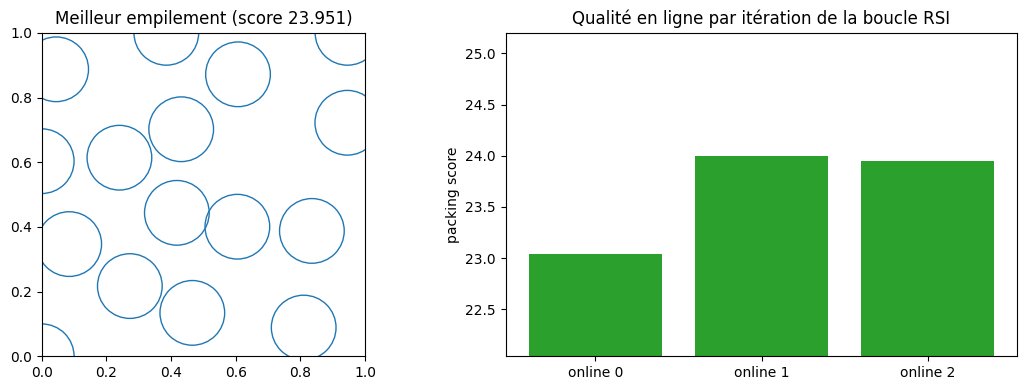

In [10]:
# Figure de synthèse : le meilleur empilement trouvé + la trajectoire de la boucle RSI
bnode = tree_best(pool[-1])

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
ax = axes[0]
for (x, y) in bnode.config:
    ax.add_patch(plt.Circle((x, y), R_MAX, fill=False, color="tab:blue"))
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_aspect("equal")
ax.set_title(f"Meilleur empilement (score {bnode.score:.3f})")
axes[1].bar([h[0] for h in history], [h[2] for h in history], color="tab:green")
q_hist = [h[2] for h in history]
axes[1].set_ylim(min(q_hist) - 1.0, max(q_hist) * 1.05)
axes[1].set_ylabel("packing score")
axes[1].set_title("Qualité en ligne par itération de la boucle RSI")
plt.tight_layout()
plt.show()

**Lecture de la figure de synthese.** `<Figure size 1100x400 with 2 Axes>` : a gauche l'empilement final — les 16 cercles espaces au mieux, la configuration dont le score sature a 24.0 ; a droite la trajectoire de la boucle RSI, les trois points online 23.0409, 24.0000, 23.9515 relus en courbe. C'est la figure a montrer pour le message central du notebook : le saut de qualite vient du choix de POLITIQUE (passer de K = 4 elitaire a K = 8 elitaire), pas d'une amelioration de l'agent — `mutate` n'a pas change d'un caractere entre le premier et le dernier point.


## 9. Exercices

Les trois exercices réutilisent les briques ci-dessus (`Node`, `expand`, `replay`,
`dream`). Aucun ne casse l'exécution du notebook : chaque cellule s'exécute telle
quelle et affiche « à compléter ».

### Exercice 1 — UCB1 : explorer là où l'incertitude est grande

`FixedRefinement` est purement élitiste, `EpsilonGreedy` diversifie au hasard. UCB1
(RL-13) fait mieux : bonus d'exploration proportionnel à $1/\sqrt{\text{visites}}$.
Branchez-la dans `replay` puis dans `dream` et comparez.

In [11]:
# Exercice 1 — politique UCB1
# Etape 1 : compléter select() : argmax (score + c * sqrt(log(total) / visits))
# Etape 2 : décommenter et comparer le replay d'UCB1 aux politiques de la GRID
# Indice : chaque Node porte .visits ; total = somme des visits de la frontière.
class UCB1:
    """Exploration upper-confidence-bound : le meilleur score connu, plus un
    bonus d'incertitude qui décroît avec les visites du nœud."""

    def __init__(self, c=0.5, batch_size=4):
        self.c = c
        self.batch_size = batch_size

    def select(self, frontier, rng):
        # TODO étudiant
        pass


# pol_ucb = UCB1()
# print(replay(pool[0], pol_ucb, random.Random(1))[0])
print("Exercice à compléter : implémenter select() de UCB1 puis décommenter.")

Exercice à compléter : implémenter select() de UCB1 puis décommenter.


**Lecture du stub — exercice 1, UCB1.** `Exercice à compléter : implémenter select() de UCB1 puis décommenter.` La formule est donnee par le squelette lui-meme : `score + c * sqrt(log(total) / visits)` — le meilleur score connu, plus un bonus qui grossit pour les noeuds peu visites. C'est le troisieme type de politique apres l'elitisme pur (FixedRefinement) et la diversification uniforme (EpsilonGreedy), et la meme idee que le bonus d'exploration de Dyna-Q+ : un terme additif qui envoie la ou l'incertitude est grande. La question de comparaison, une fois branche dans `replay` puis `dream` : UCB1 depasse-t-il les politiques de la GRID au classement du reve (Eq. 1), et ce classement survit-il au test online comme celui de K = 8 a survecu ?


### Exercice 2 — le compromis de l'Eq. 1 : balayer β₁ et β₂

Le classement du rêve dépend des poids : β₁ punit le coût, β₂ récompense la largeur.
Balayez la grille et observez la bascule du classement.

In [12]:
# Exercice 2 — sensibilité de l'Eq. 1
# Etape 1 : balayer BETA1 dans [0, 0.05, 0.1] et BETA2 dans [0, 0.5, 1.0]
# Etape 2 : pour chaque couple, relancer dream(pool, GRID, ...) et noter la politique choisie
# Etape 3 : à partir de quel β₁ le coût écrase-t-il la qualité ?
# Indice : value() lit BETA1/BETA2 globaux à chaque appel — redéfinissez-les
#          (globals()['BETA1'] = ...) avant chaque dream(), puis restaurez.
result = None  # TODO étudiant : tableau (β₁, β₂) → politique choisie
print("Exercice à compléter : balayage (β₁, β₂) du classement dream().")

Exercice à compléter : balayage (β₁, β₂) du classement dream().


### Exercice 3 — replay budgété : quand une branche manque, elle coûte

Le replay de ce notebook est **optimiste** : si la politique veut un enfant absent de
l'arbre, la marche s'arrête et c'est gratuit. Rendez-le honnête : une branche manquante
coûte 1 (il faudrait la payer pour de vrai). Quand le classement du rêve bascule-t-il
entre gratuit et budgété ?

In [13]:
# Exercice 3 — replay budgété
# Etape 1 : écrire replay_budgate(root, policy, rng, budget) : une marche qui
#           « sort » de l'arbre enregistré paie 1 par branche manquante
# Etape 2 : comparer les classements dream() gratuit vs budgété sur le même pool
# Indice : une ε-greedy sort de l'enregistré avec probabilité ε à chaque pas ;
#          représentez le budget consommé comme un compteur de marches.
print("Exercice à compléter : variant de replay() avec coût de branche manquante.")

Exercice à compléter : variant de replay() avec coût de branche manquante.


**Lecture du stub — exercice 3, le prix des 5 pas.** `Exercice à compléter : variant de replay() avec coût de branche manquante.` Le principe est pose ci-dessus (branche absente = 1) ; la lecture chiffree repart des deux replays gratuits du haut du notebook : l'elitiste a suivi 21 pas dans l'arbre enregistre, `EpsilonGreedy(eps=0.3, K=8)` s'est arretee a 5 pas — et ni l'un ni l'autre n'a rien paye (`0 appel payé`). Rendre la sortie couteuse ne change rien pour la premiere mais transforme la seconde : ses marches courtes deviennent une dette visible dans Eq. 1. L'indice de la source donne le compteur (`sort de l'enregistré avec probabilité ε à chaque pas`) ; noter que chez la politique large la sortie a deux causes — le tirage eps, et des candidats K = 8 face a des noeuds qui n'enregistrent que 4 enfants — un compteur honnete doit voir les deux.


## 10. Conclusion : le tiers manquant entre moteur et politique

Ce notebook relie trois fils du cours qui ne se touchaient pas :

- **RL-8 (Dyna)** : planifier depuis un modèle appris. Dream-RSI est ce geste, transposé
  — le « modèle » est l'historique de découverte lui-même ;
- **RL-3 (replay) et RL-9 (off-policy)** : évaluer une politique sur des données
  historiques sans les regénérer — ici, l'évaluation porte sur des **politiques
  d'exploration**, pas sur des actions ;
- **2.11-Régularisation-Sparse-LASSO** et sa comparaison SOTA
  (le solveur que le papier découvre automatiquement est le benchmark du cours) ;
- **Epic #12373 (MGS vs mealpy)** : les benchmarks circle packing / autocorrélation du
  papier sont exactement ce terrain — Dream-RSI y ajoute le tiers manquant : au-dessus
  du choix de *moteur*, le choix de *politique d'exploration* qui l'orchestre.

**À retenir** : (1) l'historique de recherche est un actif — un simulateur rejouable à
coût nul ; (2) quand la politique d'exploration est du code, elle devient elle-même
optimisable, par rêve, avec une garantie de non-régression *sur le replay* ; (3) le
replay brut bat la guidance sémantique — la structure fine vaut plus que le résumé.